# Daily Challenge: Data Handling and Analysis in Python

Objectifs :
1. Charger le dataset *Data Science Job Salary*.
2. Normaliser la colonne `salary` avec Min-Max Scaling.
3. Réduire la dimensionnalité avec PCA.
4. Agréger les données par niveau d'expérience et calculer le salaire moyen et médian.


In [2]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv('datascience_salaries.csv')

print("Dimensions :", df.shape)
df.head()


Dimensions : (1171, 7)


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


## Exploration rapide

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1171 non-null   int64 
 1   job_title         1171 non-null   object
 2   job_type          1171 non-null   object
 3   experience_level  1171 non-null   object
 4   location          1171 non-null   object
 5   salary_currency   1171 non-null   object
 6   salary            1171 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 64.2+ KB


In [4]:

df.describe(include='all')


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
count,1171.000000,1171,1171,1171,1171,1171,1171.000000
unique,NaN,5,2,4,320,3,NaN
top,NaN,Data scientist,Full Time,Senior,London,USD,NaN
freq,NaN,394,1136,727,75,1157,NaN
mean,931.620837,NaN,NaN,NaN,NaN,NaN,64836.037575
std,647.445266,NaN,NaN,NaN,NaN,NaN,32551.767046
min,0.000000,NaN,NaN,NaN,NaN,NaN,30000.000000
25%,364.500000,NaN,NaN,NaN,NaN,NaN,45000.000000
50%,815.000000,NaN,NaN,NaN,NaN,NaN,63000.000000
75%,1504.500000,NaN,NaN,NaN,NaN,NaN,68000.000000


## 1. Normalisation Min-Max de la colonne salary

In [5]:

scaler = MinMaxScaler()

df['salary_normalized'] = scaler.fit_transform(df[['salary']])

df[['salary', 'salary_normalized']].head()


,salary,salary_normalized
0,149000,0.601010
1,120000,0.454545
2,68000,0.191919
3,120000,0.454545
4,149000,0.601010


In [6]:

print("Valeur min normalisée :", df['salary_normalized'].min())
print("Valeur max normalisée :", df['salary_normalized'].max())


Valeur min normalisée : 0.0
Valeur max normalisée : 1.0


## 2. Réduction de dimension avec PCA

In [7]:

# Sélection des colonnes numériques
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# Suppression des valeurs manquantes
numeric_df = numeric_df.fillna(numeric_df.mean())

# Standardisation
scaled_features = StandardScaler().fit_transform(numeric_df)

# PCA à 2 composantes
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print("Variance expliquée :")
print(pca.explained_variance_ratio_)

pca_df.head()


Variance expliquée :
[0.66674005 0.33325995]


,PC1,PC2
0,3.636314,-1.493641
1,2.376053,-1.471852
2,0.116216,-1.436780
3,2.376099,-1.468762
4,3.636428,-1.485916


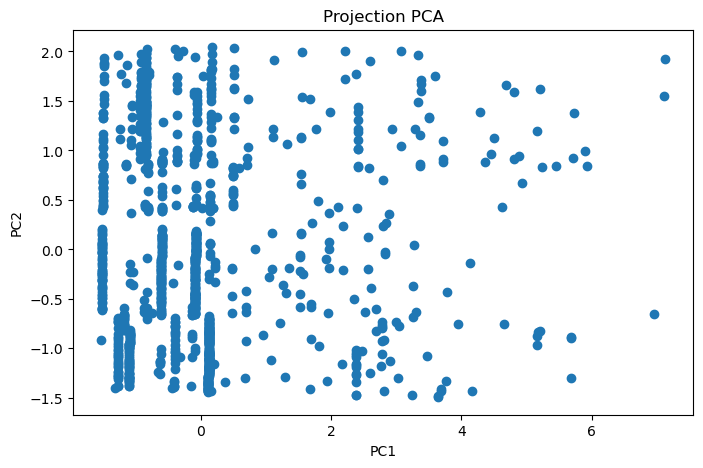

In [8]:

plt.figure(figsize=(8,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title('Projection PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 3. Agrégation par niveau d'expérience

In [9]:

salary_stats = (
    df.groupby('experience_level')['salary']
      .agg(['mean', 'median'])
      .reset_index()
)

salary_stats.columns = [
    'experience_level',
    'average_salary',
    'median_salary'
]

salary_stats


,experience_level,average_salary,median_salary
0,Entry,36111.111111,30000.0
1,Executive,76076.923077,46000.0
2,Mid,51786.885246,51000.0
3,Senior,75088.033012,68000.0


## Conclusion

- Les salaires ont été normalisés entre 0 et 1.
- PCA a permis de réduire les dimensions à deux composantes principales.
- Les salaires moyens et médians ont été calculés pour chaque niveau d'expérience.
